In [13]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from scipy import stats

### Problem 1

In [ ]:
# null hypothesis H0: breaking strength y >= 150 psi
# alternative H1: breaking strength y < 150 psi
# average of the results
y_bar_01 = np.array([145,153,150,147]).mean()
# the standard error of the mean
sigma_01 = 3
y_se_01 = sigma_01 / np.sqrt(4) # 4 is the sample size
print(f'The mean and the standard error of the tests are: {y_bar_01} and {y_se_01}')

The mean and the standard error of the tests are: 148.75 and 1.5


In [15]:
# p value larger than alpha=0.05. cannot reject the null hypothesis
print(f'The p value is {stats.norm.cdf((y_bar_01 - 150)/y_se_01).round(3)}, larger than alpha=0.05. The null hypothesis cannot be rejected.')

The p value is 0.202, larger than alpha=0.05. The null hypothesis cannot be rejected.


In [16]:
# 95% confidence interval on the mean breaking strength
print(f'The 95% confidence interval on the mean breaking strength is from {(y_bar_01 + stats.norm.ppf(0.025) * y_se_01).round(1)} to {(y_bar_01 + stats.norm.isf(0.025) * y_se_01).round(1)}')

The 95% confidence interval on the mean breaking strength is from 145.8 to 151.7


### Problem 2
* null hypothesis (H0): the viscosity of the sample detergent is 800 centistokes.
* alternative hypothesis (H1): the viscosity of the sample detergent is 800 centistokes.

In [17]:
# the standard deviation of the viscosity of the detergent
sigma_02 = 25
# average of the tests:
y_bar_02 = 812
# The standard error of the test mean:
y_se_02 = 25/np.sqrt(16)

print(f'''
      the standard deviation of the viscosity of the detergent is {sigma_02},
      the average of the tests is {y_bar_02}, 
      and the standard error of the average is {y_se_02}
''')


      the standard deviation of the viscosity of the detergent is 25,
      the average of the tests is 812, 
      and the standard error of the average is 6.25



In [18]:
# p value for the test mean
p_02 = stats.norm.sf(y_bar_02 - 800, scale=y_se_02) * 2
print(f'The p value for the test is {p_02.round(3)}, larger than alpha (0.05), meaning there is no enough evidence to reject the null hypothesis.')

The p value for the test is 0.055, larger than alpha (0.05), meaning there is no enough evidence to reject the null hypothesis.


In [19]:
# the 95% confidence interval
lower_02 = y_bar_02 + stats.norm.ppf(0.025)*y_se_02
upper_02 = y_bar_02 + stats.norm.isf(0.025)*y_se_02
print(f'The 95% confidence interval on the mean is from {lower_02.round(1)} to {upper_02.round(1)}')

The 95% confidence interval on the mean is from 799.8 to 824.2


### Problem 3

The null hypothesis (H0): the diameter of the shaft is 0.255 inches ($d = \mu$) 

The alternative hypothesis (H1): the diameter is not 0.255 inches (d $\ne \mu$)

In [20]:
# the standard deviation of the shaft diameter
sigma_03 = 0.0001
# The sample size, the sample average and the standard error
n_03 = 10
d_bar_03 = 0.2545
d_se_03 = sigma_03 / np.sqrt(n_03)

print(f'The standard error of the mean is {d_se_03.round(6)}')

The standard error of the mean is 3.2e-05


In [21]:
# find the p value of the test
p_03 = stats.norm.cdf(d_bar_03-0.255, scale=d_se_03) * 2
alpha = '\N{GREEK SMALL LETTER ALPHA}'
print(f'The p value of the test is {p_03:.2e}, significant less than the {alpha}, meaning the null hypothesis can be rejected. The diameter is not 0.255 inches.')

The p value of the test is 2.60e-56, significant less than the α, meaning the null hypothesis can be rejected. The diameter is not 0.255 inches.


In [22]:
# 95% confidence interval of the mean
lower_03 = d_bar_03 + stats.norm.ppf(0.025, scale=d_se_03)
upper_03 = d_bar_03 + stats.norm.isf(0.025, scale=d_se_03)
print(f'The 95% confidence interval for the sample mean is from {lower_03.round(4)} to {upper_03.round(4)}')

The 95% confidence interval for the sample mean is from 0.2544 to 0.2546


### Problem 4

In [23]:
# This means it is 0.5 from the mean to the upper limit (or lower limit) of the 95% confidence interval, so the statistic corresponding to the surviving function at 0.025 (for the standard normal distribution) is
z_04 = stats.norm.isf(0.025)
print(f'The Z statistic corresponding to the surviving function at 0.025 is {z_04.round(3)}')

The Z statistic corresponding to the surviving function at 0.025 is 1.96


Suppose sample size is $n$, the standard error of the sample mean is $\frac{\sigma}{\sqrt{n}}$. It can be calculated from the distance from mean to the upper limit (0.5) and the z statistic (1.96)


In [24]:
# the standard deviation of the viriable is 
sigma_04 = np.sqrt(9)
# the standard error of the sample mean also
se_04 = 0.5 / z_04
# The sample size n
n_04 = (sigma_04 / se_04)**2
print(f'The sample size is {int(np.ceil(n_04))}')

The sample size is 139


### Problem 5

The null hypothesis (H0): the shelf life of the beverage $\leq$ 120.
The alternative hypothesis (H1): the shelf life $>$ 120

In [25]:
df_05 = pd.DataFrame({
    'days': [108,124,124,106,115,138,163,159,134,139]
})
arr_05 = df_05.to_numpy().flatten()
arr_05, arr_05.mean(), arr_05.std(ddof=1)

(array([108, 124, 124, 106, 115, 138, 163, 159, 134, 139]),
 np.float64(131.0),
 np.float64(19.544820285692065))

In [26]:
# calcualte t statistic,9 degree of freedom
t_05 = (120 - arr_05.mean()) / arr_05.std(ddof=1)
# Calculate the p value
p_05 = stats.t.cdf(t_05, df=9)
print(f'The p value of the test is {p_05.round(3)}')
# 99% confidence interval of the sample mean
lower_05 = arr_05.mean() + stats.t.ppf(0.005, df=9)*arr_05.std(ddof=1)
upper_05 = arr_05.mean() + stats.t.isf(0.005, df=9)*arr_05.std(ddof=1)
print(f'The 95% confidence interval of the sample mean is from {lower_05.round(1)} to {upper_05.round(1)}')
print('There is no enough evidence to reject the null hypothesis.')

The p value of the test is 0.294
The 95% confidence interval of the sample mean is from 67.5 to 194.5
There is no enough evidence to reject the null hypothesis.


### Problem 6

([<matplotlib.axis.YTick at 0x14eec060550>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

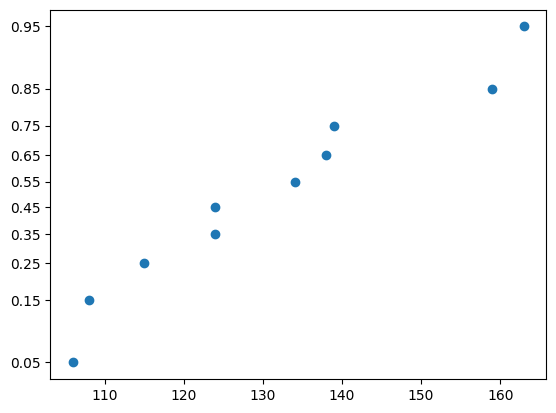

In [27]:
# plot the normal probability plot
plt.scatter(sorted(arr_05), stats.norm.ppf(np.linspace(0,1,11)[:-1]+1/10/2))
# change the scale of y axis
plt.yticks(stats.norm.ppf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

The shelf life data can be adequately described as a normal distribution. The violation of normality gives small affect on the results as long as it is randomized sampling.

### Problem 7

In [28]:
df_07 = pd.DataFrame({
    'hours': [159,224,222,149,280,379,362,260,101,179,168,485,212,264,250,170]
})

arr_07 = df_07.to_numpy().flatten()
arr_07

array([159, 224, 222, 149, 280, 379, 362, 260, 101, 179, 168, 485, 212,
       264, 250, 170])

The null hypothesis (H0): the repair time $\le$ 225 hours.

The alternative hypothesis (H1): the repair time $>$ 225 hours.

In [29]:
print(f'the mean is {arr_07.mean().round(1)} and the standard error of the mean is {arr_07.std(ddof=1).round(1)}')

the mean is 241.5 and the standard error of the mean is 98.7


In [30]:
# find the p value the test
p_07 = stats.t.sf(arr_07.mean()-225, scale=arr_07.std(ddof=1), df=15)
print(f'the p value of the test is {p_07.round(2)}, larger than the {alpha}=0.05. There is no enough evidence to reject the null hypothesis')

the p value of the test is 0.43, larger than the α=0.05. There is no enough evidence to reject the null hypothesis


In [31]:
# 95% confidence interval
lower_07 = arr_07.mean() + stats.t.ppf(0.025,df=15)*arr_07.std(ddof=1)
upper_07 = arr_07.mean() + stats.t.isf(0.025,df=15)*arr_07.std(ddof=1)
print(f'The 95% confidence interval of the mean is from {lower_07.round(2)} to {upper_07.round(2)}')

The 95% confidence interval of the mean is from 31.07 to 451.93


### Problem 8

([<matplotlib.axis.YTick at 0x14eebfde0d0>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

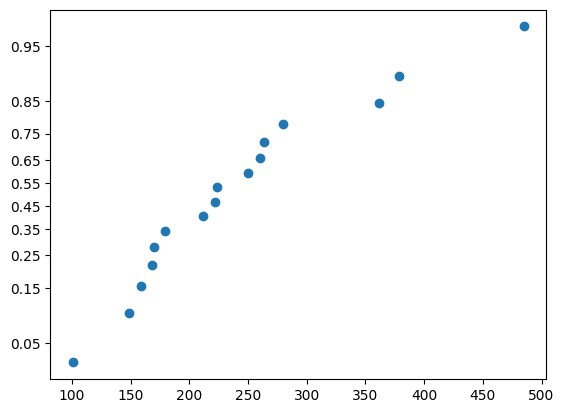

In [32]:
# plot the normal probability plot
plt.scatter(sorted(arr_07), stats.norm.ppf(np.linspace(0,1,17)[:-1]+1/16/2))
# change the scale of y axis
plt.yticks(stats.norm.ppf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

It is clear that the data cannot be adequately modeled by a normal distribution. there is obvious deviations as the time exceeds 300 hours

### Problem 9

null hypothesis (H0): Both machines fill to the same net volume $V_1 = V_2$

alternative hypothesis (H1): The two machines do not fill to the same net volume $V_1 \ne V_2$

In [33]:
df_09 = pd.DataFrame({
    'm1': [16.03,16.04,16.05,16.05,16.02,16.01,15.96,15.98,16.02,15.99],
    'm2': [16.02,15.97,15.96,16.01,15.99,16.03,16.04,16.02,16.01,16.00]
})

In [34]:
# sigma1 and sigma2 are known. 
# find the z statistic
z_09 = (df_09.m1.mean() - df_09.m2.mean())/np.sqrt((0.015**2+0.018**2)/10)
p_09 = stats.norm.sf(z_09) * 2
print(f'The p value {p_09.round(2)} is larger than the {alpha} (0.05), thus there is no enough evidence to reject the null hypothesis.')


The p value 0.18 is larger than the α (0.05), thus there is no enough evidence to reject the null hypothesis.


In [35]:
lower_09 = (df_09.m1.mean() - df_09.m2.mean()) - stats.norm.isf(0.025)*np.sqrt((0.015**2+0.018**2)/10)
upper_09 = (df_09.m1.mean() - df_09.m2.mean()) + stats.norm.isf(0.025)*np.sqrt((0.015**2+0.018**2)/10)
print(f'The 95% confidence interval on the difference in mean fill volume for the two machines is from {lower_09.round(3)} to {upper_09.round(3)}')

The 95% confidence interval on the difference in mean fill volume for the two machines is from -0.005 to 0.025


### Problem 10
null hypothesis (H0): the breaking strength of plastic 1 exceeds that of plastic 2 by at least 10 psi ($\mu_1 - \mu_2 \ge 10$)

alternative hypothesis (H1): the breaking strength of plastic 1 does not exceed that of plastic 2 by at leat 10 psi ($\mu_1 - \mu_2 < 10$)

In [36]:
# the standard deviation is known
# calculate the z statistic
y1_bar_10 = 162.5
y2_bar_10 = 155.0

z_10 = (y1_bar_10 - y2_bar_10 - 10) / (1.0*np.sqrt(1/10+1/12))
p_10 = stats.norm.cdf(z_10)
print(f'The p value of the test is {p_10:.2e}, smaller than the {alpha} (0.01), thus the null hypothesis is rejected.')

The p value of the test is 2.63e-09, smaller than the α (0.01), thus the null hypothesis is rejected.


In [37]:
# calculate the 99% confidence interval
lower_10 = (y1_bar_10 - y2_bar_10) - stats.norm.sf(0.005) * (1.0*np.sqrt(1/10+1/12))
upper_10 = (y1_bar_10 - y2_bar_10) + stats.norm.sf(0.005) * (1.0*np.sqrt(1/10+1/12))
print(f'The 99% confidence interval on the true mean difference in breaking strength is from {lower_10.round(1)} to {upper_10.round(1)}')

The 99% confidence interval on the true mean difference in breaking strength is from 7.3 to 7.7


### Problem 11

In [38]:
df_11 = pd.DataFrame({
    't1': [65,81,57,66,82,82,67,59,75,70],
    't2': [64,71,83,59,65,56,69,74,82,79]
})

In [39]:
#  95% interval
print(f'''
      the variance ratio (f statistic) of the two set of burning times {(df_11.t1.var(ddof=1) / df_11.t2.var()).round(3)} 
      is within the 95% confidence interval of the variance ratio from {stats.f.ppf(0.025, dfn=9, dfd=9).round(3)} to {stats.f.isf(0.025,dfn=9, dfd=9).round(3)}.
      Therefore, the null hypothesis cannot be rejected and the two variances are equal at the level of {alpha} = 0.05
      ''')



      the variance ratio (f statistic) of the two set of burning times 0.978 
      is within the 95% confidence interval of the variance ratio from 0.248 to 4.026.
      Therefore, the null hypothesis cannot be rejected and the two variances are equal at the level of α = 0.05
      


In [40]:
# calcualte the p value from f statistic
stats.f.cdf(df_11.t1.var(ddof=1) / df_11.t2.var(), dfn=9, dfd=9) * 2 # the f statistic is smaller than 1, so use cdf not isf

np.float64(0.9743664928217836)

In [41]:
stats.ttest_ind(df_11.t1, df_11.t2)

TtestResult(statistic=np.float64(0.04800768184369234), pvalue=np.float64(0.9622387844779035), df=np.float64(18.0))

In [42]:
print(f'''
      it shows above that the two variances are equal at {alpha}=0.05, 
      so the p value for this test is {(stats.ttest_ind(df_11.t1, df_11.t2)[1]).round(3)}. 
      This is larger than {alpha} (0.05), so the null hypothesis cannot be rejected.

''')


      it shows above that the two variances are equal at α=0.05, 
      so the p value for this test is 0.962. 
      This is larger than α (0.05), so the null hypothesis cannot be rejected.




In [43]:
# Or to calculate manually
t_11 = (df_11.t1.mean() - df_11.t2.mean()) / np.sqrt((df_11.t1.var() /2 + df_11.t2.var()/2) * (1/10 + 1/10)) # this is the t statistic

print(f'''
      it shows above that the two variances are equal at {alpha}=0.05, 
      so the p value for this test is {(stats.t.sf(t_11, df=18)*2).round(3)}. 
      This is larger than {alpha} (0.05), so the null hypothesis cannot be rejected.

''')




      it shows above that the two variances are equal at α=0.05, 
      so the p value for this test is 0.962. 
      This is larger than α (0.05), so the null hypothesis cannot be rejected.




([<matplotlib.axis.YTick at 0x14eebf9e0d0>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

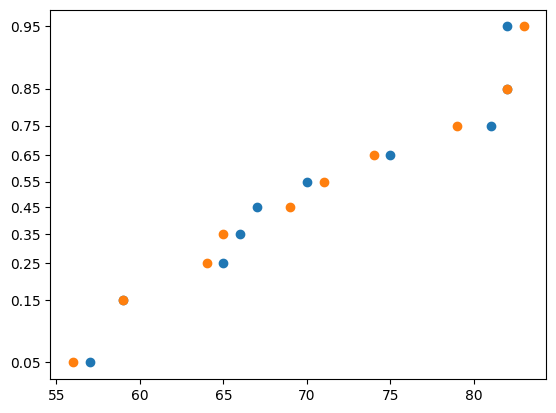

In [44]:
# check the normality for both type 1 and type 2 by ploting the data
plt.scatter(df_11.t1.sort_values(), -stats.norm.isf(np.linspace(0,1,11)[:-1]+1/20))
plt.scatter(df_11.t2.sort_values(), -stats.norm.isf(np.linspace(0,1,11)[:-1]+1/20))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

the assumption of normality of the two dataset is mildly violated. As long as the samples are randomly collected, the t-test result is still valid. The plot also show the same slope, consistent with the variance f test

### Problem 1
* null hypothesis (H0): the $C_2F_2$ flow rate does not affect the etch uniformity. $u_0=u_1$
* alternative hypothesis (H1): the $C_2F_2$ flow rate affects the etch uniformity. $u_0 \ne u_1$

In [45]:
df_12 = pd.DataFrame({
    'cf125': [2.7,4.6,2.6,3.0,3.2,3.8],
    'cf200': [4.6,3.4,2.9,3.5,4.1,5.1]
})

([<matplotlib.axis.YTick at 0x14eec159090>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

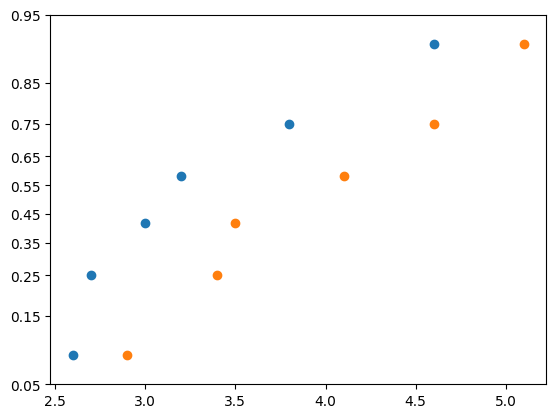

In [46]:
# plot the data to check normality
plt.scatter(df_12.cf125.sort_values(), -stats.norm.isf(np.linspace(0,1,7)[:-1]+1/12))
plt.scatter(df_12.cf200.sort_values(), -stats.norm.isf(np.linspace(0,1,7)[:-1]+1/12))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

In [47]:
# Both datasets do not violate normality and the slopes of the two plots are similar, meaning similar standard deviation. 
# Let's verify it by f test
# calculate the sample variances
var1_12 = df_12.cf125.var(ddof=1) 
var2_12 = df_12.cf200.var()# ddof is defaulted at 1
pf_12 = min(stats.f.sf(var1_12/var2_12, dfn=5, dfd=5), stats.f.cdf(var1_12/var2_12, dfn=5, dfd=5))*2
print(f'The p value for the f test on the variance is {pf_12.round(3)}, larger than the {alpha}=0.05. There is no enough evidence to reject the hypothesis that the flow rate does not affect the variance.')

The p value for the f test on the variance is 0.869, larger than the α=0.05. There is no enough evidence to reject the hypothesis that the flow rate does not affect the variance.


In [48]:
# We already showed that the same standard deviation btw the two dataset, so we can use stats.ttest_ind method to get the p value
p_12 = stats.ttest_ind(df_12.cf125, df_12.cf200)[1]
print(f'''
the p value {p_12.round(3)} is larger than {alpha}=0.05. There is not enough evidence to reject the null hypothesis.
''')



the p value 0.207 is larger than α=0.05. There is not enough evidence to reject the null hypothesis.



In [49]:
# or we could manually calculate the p value
# the estimate of the common variance with 10 degree of freedom
var_12 = (var1_12 * (6-1) + var2_12*5)/(6+6-2)
# the t statistic
t_12 = (df_12.cf125.mean() - df_12.cf200.mean()) / np.sqrt(var_12*(1/6+1/6))
# the p value
p_12_2 = min(stats.t.sf(t_12, df=10), stats.t.cdf(t_12, df=10)) * 2
p_12_2.round(3)

np.float64(0.207)

<Axes: >

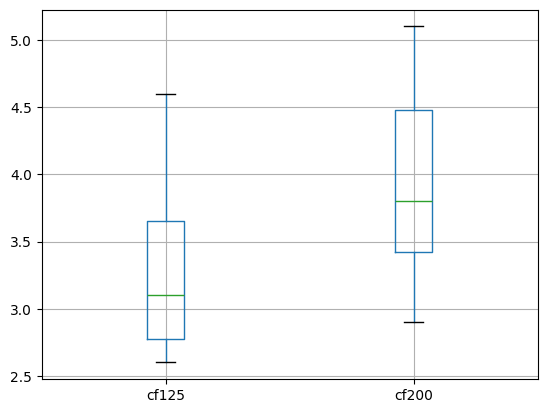

In [50]:
# box plots below clearly show that the similar variance and the mean difference is not significant comparing the variance scale.
df_12.boxplot()

###

### Problem 13

(a)
* null hypothesis ($H_0$): the variances are the same ($S_1^2 = S_2^2$)
* alternative hypothesis ($H_1$): the variances are not the same ($S_1^2 \ne S_2^2$)
* using f test with $\alpha = 0.05$

In [51]:
print(f'the p value of the test is {2*stats.f.sf(101.17/94.73, dfn=7, dfd=8).round(3)}, so there is no enough evidence to reject the null hypothesis')

the p value of the test is 0.918, so there is no enough evidence to reject the null hypothesis


(b)
* null hypothesis ($H_0$): the means are the same ($\bar{y}_1 \le \bar{y}_2$)
* alternative hypothesis ($H_1$): the variances are not the same ($\bar{y}_1 > \bar{y}_2$)
* using t test with $\alpha = 0.05$

In [52]:
# calculate the t statistic
sp2_13 = (101.17*(8-1)+94.73*(9-1))/8+9-2
t_13 = (10.2-12.5)/np.sqrt(sp2_13*(1/8+1/9))
# calculate p value
p_13 = stats.t.cdf(t_13, df=15)
print(f'the p value for the test is {p_13.round(3)}, larger than {alpha}=0.05. There is no enough evidence to reject the null hypothesis')

the p value for the test is 0.368, larger than α=0.05. There is no enough evidence to reject the null hypothesis


### Problem 14

In [53]:
arr_14 = np.array([5.34,6.65,4.76,5.98,7.25,6,7.55,5.54,5.62,6.21,5.97,7.35,5.44,4.39,4.98,5.25,6.35,4.61,6,5.32])

In [54]:
-stats.norm.isf(np.linspace(0,1,len(arr_14)+1)[:-1]+1/2/len(arr_14))

array([-1.95996398, -1.43953147, -1.15034938, -0.93458929, -0.75541503,
       -0.59776013, -0.45376219, -0.31863936, -0.18911843, -0.06270678,
        0.06270678,  0.18911843,  0.31863936,  0.45376219,  0.59776013,
        0.75541503,  0.93458929,  1.15034938,  1.43953147,  1.95996398])

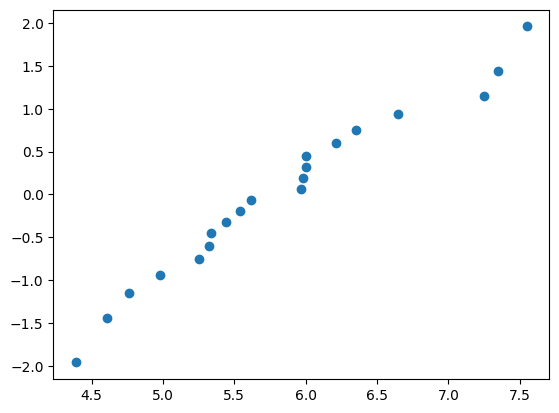

In [55]:
# check normality first by ploting. No violation found
plt.scatter(sorted(arr_14), -stats.norm.isf(np.linspace(0,1,len(arr_14)+1)[:-1]+1/2/len(arr_14)))

In [56]:
# the estimate of the variance from the dataset
arr_14.var(ddof=1)
# use chi-square distribution method from stats to calculate the chi2 statistics corresponding to 1-alpha/2 and alpha/2
stats.chi2.isf(0.025,df=19), stats.chi2.isf(0.975,df=19)
print(f'the 95% confidence interval estimate of variance is from {((20-1)*arr_14.var(ddof=1)/stats.chi2.isf(0.025,df=19)).round(3)} to {((20-1)*arr_14.var(ddof=1)/stats.chi2.isf(0.975,df=19)).round(3)}')

the 95% confidence interval estimate of variance is from 0.457 to 1.686


* null hypothesis ($H_0$): variance of the data is 1.0 ($\sigma ^2 = 1.0$)
* alternative hypothesis ($H_1$): variance of the data is not 1.0 ($\sigma ^2 \ne 1.0$)
* $\alpha = 0.05$
* Above we already show the 95% confidence interval estimate of the variance, which contains 1.0. The null hypothesis cannot be rejected.
* The normality was tested above with plotting. The normality assumption is key in this problem, as the chi2 distribution is based on normal distribution.

### Problem 15
* this is a paired t test. use stats.ttest_rel
* null hypothesis ($H_0$): no significant difference or $\mu _1 = \mu _2$ or $\mu _d = 0$
* null hypothesis ($H_1$): significant difference or $\mu _1 \ne \mu _2$ or $\mu _d \ne 0$
* $\alpha = 0.05$


In [57]:
df_15 = pd.DataFrame({
    'inspector': np.arange(12)+1,
    'caliper1': [0.265,0.265,0.266,0.267,0.267,0.265,0.267,0.267,0.265,0.268,0.268,0.265],
    'caliper2': [0.264,0.265,0.264,0.266,0.267,0.268,0.264,0.265,0.265,0.267,0.268,0.269]
})

In [58]:
stats.ttest_rel(df_15.caliper1, df_15.caliper2)

TtestResult(statistic=np.float64(0.4317877695883728), pvalue=np.float64(0.6742372381662263), df=np.int64(11))

In [59]:
# step by step analysis
# the paired differences 
d_15 = df_15.caliper1 - df_15.caliper2
d_15_mean = d_15.mean() # mean
d_15_sp = d_15.std(ddof=1) # sample standard deviation
# calculate the t statistic
t_15 = d_15_mean/(d_15_sp/np.sqrt(12))
p_15 = stats.t.sf(d_15_mean, scale=d_15_sp/np.sqrt(12), df=12-1)*2
print(f'''the p value for the test is {p_15.round(3)}, larger than the {alpha}. There is no evidence to reject the null hypothesis.
      The 95% confidence interval on the difference in mean diameter measurements is from {(d_15_mean + stats.t.isf(0.975, scale=d_15_sp/np.sqrt(12), df=11)).round(3)} to {(d_15_mean + stats.t.isf(0.025, scale=d_15_sp/np.sqrt(12), df=11)).round(3)}''')

the p value for the test is 0.674, larger than the α. There is no evidence to reject the null hypothesis.
      The 95% confidence interval on the difference in mean diameter measurements is from -0.001 to 0.002


### Problem 16

* the null hypothesis ($H_0$): no difference or $\mu_1 = \mu_2$ or $\mu_d = 0$
* the alternative hypothesis ($H_1$): significant difference or $\mu_1 \ne \mu_2$ or $\mu_d \ne 0$
* $\alpha$ = 0.05
* this is a paired t test, so use **stats.ttest_rel**

In [60]:
df_16 = pd.DataFrame({
    'girder': [f'S{i}/1' for i in range(1,6)] + [f'S2/{i}' for i in range(1,5)],
    'K': [1.186,1.151,1.322,1.339,1.2,1.402,1.365,1.537,1.559],
    'L': [1.061,0.992,1.063,1.062,1.065,1.178,1.037,1.086,1.052]
})

df_16

,girder,K,L
0,S1/1,1.186,1.061
1,S2/1,1.151,0.992
2,S3/1,1.322,1.063
3,S4/1,1.339,1.062
4,S5/1,1.200,1.065
5,S2/1,1.402,1.178
6,S2/2,1.365,1.037
7,S2/3,1.537,1.086
8,S2/4,1.559,1.052


In [61]:
# use the available method from scipy
stats.ttest_rel(df_16.K, df_16.L)

TtestResult(statistic=np.float64(6.0819394375848255), pvalue=np.float64(0.0002952954627860406), df=np.int64(8))

In [62]:
# run the analysis step by step
# the paried differences
d_16 = df_16.K - df_16.L
# the mean of the difference
d_16_mean = d_16.mean()
# the sample standard deviation of the paired differences
d_16_std = d_16.std(ddof=1)
# the standard error for the mean, also for the t test scale
d_16_mean_se = d_16_std / np.sqrt(9)
# the t statistic
t_16 = d_16_mean / d_16_mean_se
# the p value
p_16 = min(stats.t.cdf(d_16_mean, scale=d_16_mean_se, df=9-1), stats.t.sf(d_16_mean, scale=d_16_mean_se, df=9-1))*2
print(f'''
      the p value for the test is {p_16.round(3)}, smaller than {alpha}. The null hypothesis can be rejected.
      The 95% confidence interval on the difference is from {(d_16_mean + stats.t.ppf(0.025, scale=d_16_mean_se, df=8)).round(3)} to {(d_16_mean + stats.t.isf(0.025, scale=d_16_mean_se, df=8)).round(3)}
''')


      the p value for the test is 0.0, smaller than α. The null hypothesis can be rejected.
      The 95% confidence interval on the difference is from 0.17 to 0.378



([<matplotlib.axis.YTick at 0x14eec47d6d0>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

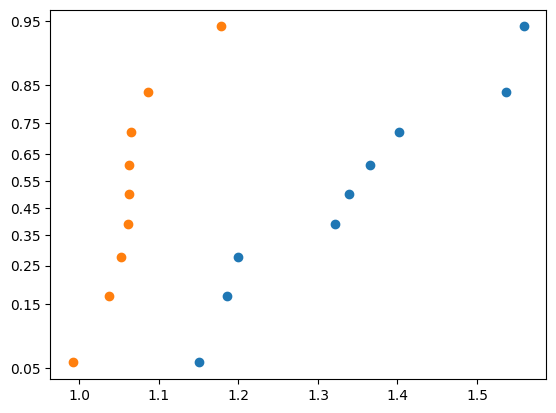

In [63]:
# check normality for both samples. 
# L method results violated the normality
plt.scatter(df_16.K.sort_values(), -stats.norm.isf(np.linspace(0,1,10)[:-1]+1/18))
plt.scatter(df_16.L.sort_values(), -stats.norm.isf(np.linspace(0,1,10)[:-1]+1/18))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

([<matplotlib.axis.YTick at 0x14eec508a50>,
 [Text(0, -1.6448536269514729, '0.05'),
  Text(0, -1.0364333894937898, '0.15'),
  Text(0, -0.6744897501960817, '0.25'),
  Text(0, -0.38532046640756773, '0.35'),
  Text(0, -0.12566134685507416, '0.45'),
  Text(0, 0.12566134685507388, '0.55'),
  Text(0, 0.38532046640756773, '0.65'),
  Text(0, 0.6744897501960817, '0.75'),
  Text(0, 1.0364333894937898, '0.85'),
  Text(0, 1.6448536269514722, '0.95')])

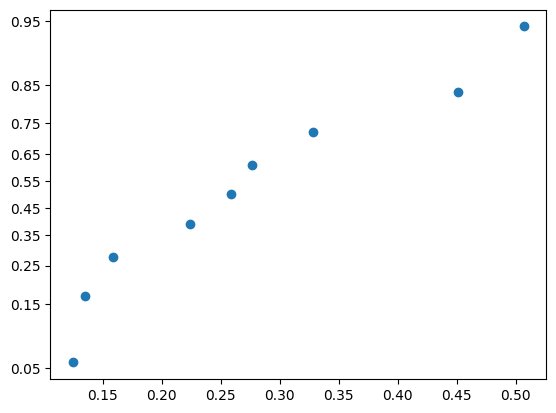

In [64]:
# check the normality for the differences. there is a slight violation of normality
plt.scatter((df_16.K - df_16.L).sort_values(), -stats.norm.isf(np.linspace(0,1,10)[:-1]+1/18))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))

If the normality assumption is only slightly violated and the samples are random, no big effect on t test

### Problem 17

In [65]:
df_17 = pd.DataFrame({
    'f1': [206,193,192,188,207,210,205,185,194,187,189,178],
    'f2': [177,176,198,197,185,188,206,200,189,201,197,203]
})

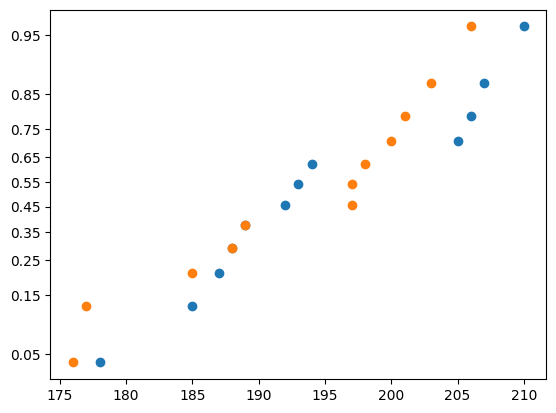

In [66]:
# check the normality by plotting. Both samples are normally distributed with equal variance.
plt.scatter(df_17.f1.sort_values(), -stats.norm.isf(np.linspace(0,1,13)[:-1]+1/24))
plt.scatter(df_17.f2.sort_values(), -stats.norm.isf(np.linspace(0,1,13)[:-1]+1/24))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.show()

check equal variances with f test
* null hypothesis ($H_0$): equal variance $\sigma_1^2 = \sigma_2^2$
* alternative hypothesis ($H_1$): not equal variances $\sigma_2^2 \ne \sigma_2^2$
* select $\alpha = 0.05$

In [67]:
# check equal variance with f test
var1_17 = df_17.f1.var(ddof=1)
var2_17 = df_17.f2.var(ddof=1)
# f statistic
f_17 = var1_17 / var2_17
p_var_17 = min(1 - stats.f.sf(f_17, dfn=11, dfd=11), stats.f.sf(f_17, dfn=11, dfd=11)) * 2
print(f'the p value for the f test is {p_var_17.round(3)}, larger than {alpha}. There is not evidence to reject the null hypothesis.')

the p value for the f test is 0.942, larger than α. There is not evidence to reject the null hypothesis.


* null hypothesis ($H_0$): $\mu_1 \le \mu_2$
* alternative hypothesis ($H_1$): $\mu_1 > \mu_2$
* select $\alpha = 0.05$

In [95]:
mean1_17 = df_17.f1.mean()
mean2_17 = df_17.f2.mean()
# since equal variances, the estimate of common standard deviation from the two samples
sp_17 = np.sqrt((var1_17 * 11 + var2_17*11)/22)
# the t statistic for the test
t_17 = (mean1_17 - mean2_17) / sp_17 / np.sqrt(1/12+1/12)
p_17 = stats.t.sf(t_17, df=22)
print(f'the p value for the test is {p_17.round(3)}, larger than {alpha}=0.05. There is no evidence to reject the null hypothesis.')

the p value for the test is 0.367, larger than α=0.05. There is no evidence to reject the null hypothesis.


In [92]:
stats.ttest_ind(df_17.f1, df_17.f2, alternative='greater')

TtestResult(statistic=np.float64(0.34483010130448505), pvalue=np.float64(0.36674847134177085), df=np.float64(22.0))

### Problem 18
* null hypothesis ($H_0$): $\mu_1 \ge \mu_2 + 3$
* alternative hypothesis ($H_1$): $\mu_1 < \mu_2 + 3$
* select $\alpha = 0.05$

In [102]:
# the t statistic for the test
t_18 = (mean1_17 - mean2_17 -3) / sp_17 / np.sqrt(1/12+1/12)
p_18 = 1 - stats.t.sf(t_18, df=22)
print(f'the p value for the test is {p_18.round(3)}, larger than {alpha}=0.05. There is no evidence to reject the null hypothesis.')

the p value for the test is 0.352, larger than α=0.05. There is no evidence to reject the null hypothesis.


In [103]:
stats.ttest_ind(df_17.f1, df_17.f2+3, alternative='less')

TtestResult(statistic=np.float64(-0.38539834851678234), pvalue=np.float64(0.3518217465269042), df=np.float64(22.0))

### Problem 19
* null hypothesis ($H_0$): equal means $\mu_1 = \mu_2$
* alternative hypothesis ($H_1$): not equal means $\mu_1 \ne \mu_2 + 3$
* equal variance
* select $\alpha = 0.05$

In [104]:
df_19 = pd.DataFrame({
    's1': [9.9,10.6,9.4,10.3,10.0,9.3,10.3,9.8],
    's2': [10.2,10.6,10.0,10.2,10.7,10.4,10.5,10.3]
})

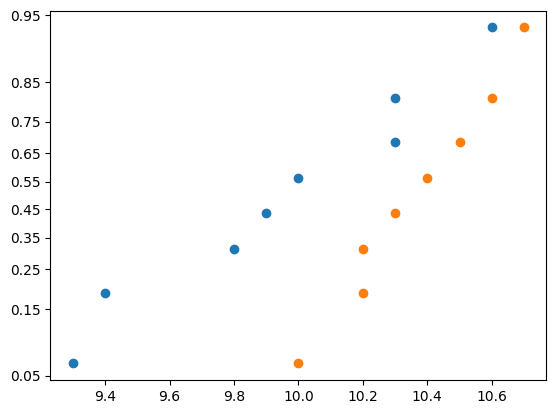

In [106]:
# check the normality by plotting. Both samples are normally distributed with unequal variance.
plt.scatter(df_19.s1.sort_values(), -stats.norm.isf(np.linspace(0,1,9)[:-1]+1/16))
plt.scatter(df_19.s2.sort_values(), -stats.norm.isf(np.linspace(0,1,9)[:-1]+1/16))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.show()

In [122]:
# sample standard deviations
sp1_19 = df_19.s1.std(ddof=1)
sp2_19 = df_19.s2.std(ddof=1)
# t statistic
t_19 = (df_19.s1.mean()-df_19.s2.mean()) / np.sqrt(sp1_19**2/8 + sp2_19**2/8)
# p value
p_19 = min(stats.t.sf(t_19, df=(sp1_19**2/8+sp2_19**2/8)**2/((sp1_19**2/8)**2/7 + (sp2_19**2/8)**2/7)),
           1-stats.t.sf(t_19, df=(sp1_19**2/8+sp2_19**2/8)**2/((sp1_19**2/8)**2/7 + (sp2_19**2/8)**2/7)))*2
lower_19 = df_19.s1.mean()-df_19.s2.mean() - stats.t.isf(0.025, scale=np.sqrt(sp1_19**2/8 + sp2_19**2/8) ,df=(sp1_19**2/8+sp2_19**2/8)**2/((sp1_19**2/8)**2/7 + (sp2_19**2/8)**2/7))
upper_19 = df_19.s1.mean()-df_19.s2.mean() + stats.t.isf(0.025, scale=np.sqrt(sp1_19**2/8 + sp2_19**2/8) ,df=(sp1_19**2/8+sp2_19**2/8)**2/((sp1_19**2/8)**2/7 + (sp2_19**2/8)**2/7))

print(f'''
      the p value for the test is {p_19.round(3)}, smaller than the {alpha}=0.05. The null hypothesis is safe to be rejected.
      the 95% confidence interval of the difference in mean is from {lower_19.round(3)} to {upper_19.round(3)}
''')



      the p value for the test is 0.043, smaller than the α=0.05. The null hypothesis is safe to be rejected.
      the 95% confidence interval of the difference in mean is from -0.809 to -0.016



In [128]:
stats.ttest_ind(df_19.s1, df_19.s2, equal_var=False).confidence_interval() # default 0.95

ConfidenceInterval(low=np.float64(-0.8093362974301064), high=np.float64(-0.015663702569892968))

### Problem 20
* null hypothesis ($H_0$): $2\mu_1 = \mu_2$
* alternative hypothesis ($H_1$): $2\mu_1 \ne \mu_2$
* assume sample size for each is $n$ and the sample means are $\bar{y}_1$ and $\bar{y}_2$
* pre-select $\alpha = 0.05$
* $\bar{y}_d = \bar{y}_1 - \bar{y}_1$
* $\sigma_d^2 = \frac{2\sigma_1^2}{n} + \frac{\sigma_2^2}{n}$
* z statistic: $z_0 = \frac{\bar{y}_d}{\sigma_d}$
* At $\alpha = 0.05$, $z_{0.025} = $ **stats.norm.isf(0.025)**
* If $|z_0| > z_{0.05}$, reject the null hypothesis.

### Problem 21
* null hypothesis ($H_0$): $\mu_1 = \mu_2$
* alternative hypothesis ($H_1$): $\mu_1 \ne \mu_2$
* The sample sizes are $n_1$ and $n_2$ and the sample means are $\bar{y}_1$ and $\bar{y}_2$
* $\bar{y}_d = \bar{y}_1 - \bar{y}_1$
* $\sigma_d^2 = \frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}$
* z statistic: $z_0 = \frac{\bar{y}_d}{\sigma_d}$
* to achieve the most powerful test, we want the largest possible $z_0$, thus the smallest common standard deviation $\sigma_d$
* This problem becomes finding the minimal of $\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}$ while keep $n_1 + n_2 = N$
* The answer is $n_1 = \frac{\sigma_1}{\sigma_1 + \sigma_2} \cdot N$ and $n_2 = \frac{\sigma_2}{\sigma_1 + \sigma_2} \cdot N$

### Problem 22
* the distribution of the sample variance $S^2$ follows the Chi-squared distribution show as follow,
$$\chi^2 = \frac{(n-1)S^2}{\sigma^2}$$
where the $\sigma^2$ is the population variance and $n$ is the sample size.
* The statistic $\chi^2$ follows a chi-squared distribution with $n-1$ degrees of freedom.
* We want the $1-\alpha$ conficence interval of $\sigma^2$, so
$$P(\chi^2_{1-\alpha/2, n-1} \le \chi^2 \le \chi^2_{\alpha/2, n-1}) = 1-\alpha$$
* Therefore,
$$\frac{(n-1)S^2}{\chi^2_{\alpha/2, n-1}} \le \sigma^2 \le \frac{(n-1)S^2}{\chi^2_{1-\alpha/2, n-1}}$$

### Problem 23
* the distribution of the sample variances ratio $\frac{S_1^2}{S_2^2}$ follows the $F$ distribution show as follow,
$$F_0 = \frac{\frac{S_1^2}{S_2^2}}{\frac{\sigma_1^2}{\sigma_2^2}}$$
where the $\sigma_1^2$ and $\sigma_2^2$ are the population variances.
* The statistic $F_0$ follows a $F$ distribution with $n_1-1$ (numerator) and $n_2-1$ (denominator) degrees of freedom, where $n_1$ and $n_2$ are the sample sizes of the two samples.
* We want the $1-\alpha$ conficence interval of $\frac{\sigma_1^2}{\sigma_2^2}$, so
$$P(F_{1-\alpha/2, n_1-1, n_2-1} \le F_0 \le F_{\alpha/2, n_1-1, n_2-1}) = 1-\alpha$$

* Therefore,
$$\frac{\frac{S_1^2}{S_2^2}}{F_{\alpha/2, n_1-1, n_2-1}} \le \frac{\sigma_1^2}{\sigma_2^2} \le \frac{\frac{S_1^2}{S_2^2}}{F_{1-\alpha/2, n_1-1, n_2-1}}$$
or
$$\frac{S_1^2}{S_2^2}F_{1-\alpha/2, n_2-1, n_1-1} \le \frac{\sigma_1^2}{\sigma_2^2} \le \frac{S_1^2}{S_2^2}F_{\alpha/2, n_2-1, n_1-1}$$

### Problem 24
* null hypothesis ($H_0$): $\mu_1 = \mu_2$
* alternative hypothesis ($H_1$): $\mu_1 \ne \mu_2$
* The two normal distributions with $\sigma_1^2 \ne \sigma_2^2$.
* The distribution of the mean difference $\bar{y}_1 - \bar{y}_2$ follows $t$ distribution,
$$t_0 = \frac{\bar{y}_1 - \bar{y}_2 - (\mu_1 - \mu_2)}{\sqrt{\frac{S_1^2}{n_1}+\frac{S_2^2}{n_2}}}$$
and the degrees of freedom is 
$$\nu = \frac{(\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2})^2}{\frac{(S_1^2/n_1)^2}{n_1-1} + \frac{(S_2^2/n_2)^2}{n_2-1}}$$
* find the $(1-\alpha)$ confidence interval for $\mu_1 - \mu_2$,
$$t_{1-\alpha/2, \nu} \le \frac{\bar{y}_1 - \bar{y}_2 - (\mu_1 - \mu_2)}{\sqrt{\frac{S_1^2}{n_1}+\frac{S_2^2}{n_2}}} \le t_{\alpha/2, \nu}$$


$$(\bar{y}_1 - \bar{y}_2)  - t_{\alpha/2, \nu} * \sqrt{\frac{S_1^2}{n_1}+\frac{S_2^2}{n_2}} \le \mu_1 - \mu_2 \le (\bar{y}_1 - \bar{y}_2) - t_{1-\alpha/2, \nu} * \sqrt{\frac{S_1^2}{n_1}+\frac{S_2^2}{n_2}}$$
$$(\bar{y}_1 - \bar{y}_2)  - t_{\alpha/2, \nu} * \sqrt{\frac{S_1^2}{n_1}+\frac{S_2^2}{n_2}} \le \mu_1 - \mu_2 \le (\bar{y}_1 - \bar{y}_2) + t_{\alpha/2, \nu} * \sqrt{\frac{S_1^2}{n_1}+\frac{S_2^2}{n_2}}$$


In [131]:
# The Portland Cement data
df_t01 = pd.DataFrame({
    'modified': [16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57],
    'unmodified': [17.50,17.63,18.285,18.00,17.86,17.75,18.22,17.90,17.96,18.15]
})

In [138]:
# Assume nonequal variances
t01_m_mean = df_t01.modified.mean()
t01_um_mean = df_t01.unmodified.mean()
t01_m_var = df_t01.modified.var(ddof=1)
t01_um_var = df_t01.unmodified.var(ddof=1)

t01_dof = (t01_m_var/10 + t01_um_var/10)**2 / ((t01_m_var/10)**2/(10-1) + (t01_um_var/10)**2/(10-1))
t_01_t = stats.t.isf(0.025, df=t01_dof)

lower_t01 = t01_m_mean - t01_um_mean - t_01_t*np.sqrt(t01_m_var/10 + t01_um_var/10)
upper_t01 = t01_m_mean - t01_um_mean + t_01_t*np.sqrt(t01_m_var/10 + t01_um_var/10)

print(f'The 95% confidence interval on the difference in the means is from {lower_t01.round(3)} to {upper_t01.round(3)}')

The 95% confidence interval on the difference in the means is from -1.432 to -0.891


In [140]:
# Or directly use the following method
stats.ttest_ind(df_t01.modified, df_t01.unmodified, equal_var=False).confidence_interval()

ConfidenceInterval(low=np.float64(-1.431703692666668), high=np.float64(-0.8912963073333253))

### Problem 25
* to create such dataset, just to make sure the much larger variance within each treatment and smaller variance within each batch

In [146]:
t_scale_25 = 2
b_scale_25 = 0.2
mean_25 = 10
data_size = 10

data_25_1 = np.random.normal(loc=mean_25, scale=t_scale_25, size=data_size)
data_25_2 = data_25_1 + np.random.normal(loc=0, scale=b_scale_25, size=data_size)

In [147]:
stats.ttest_rel(data_25_1, data_25_2)

TtestResult(statistic=np.float64(1.1387394682614205), pvalue=np.float64(0.28421427792806553), df=np.int64(9))

In [148]:
stats.ttest_ind(data_25_1, data_25_2)

TtestResult(statistic=np.float64(0.07887583857003927), pvalue=np.float64(0.9380016410346271), df=np.float64(18.0))